### Real-Time ASR with Voice Activity Detection and Interruption Handling

Enhanced Voice Interaction System with VAD and Interruption Handling

This script implements a robust voice interaction system featuring advanced voice activity detection, interruption recognition, and reliable exit mechanisms. It demonstrates real-time speech processing with visual feedback and graceful error handling.

Key Libraries Used:

    pyaudio: Real-time audio streaming

    webrtcvad: Voice activity detection

    transformers: Whisper ASR for speech recognition

    torch: Deep learning backend

    colorama/rich: Enhanced console visualization

    numpy: Audio buffer processing

Code Logic and Flow

The system operates in five states:

    LISTENING: Detect speech via VAD

    PROCESSING: Buffer audio during silence

    TRANSCRIBING: Convert speech to text

    INTERRUPTED: Handle voice interruptions

    EXITING: Graceful shutdown

Visual Flow:

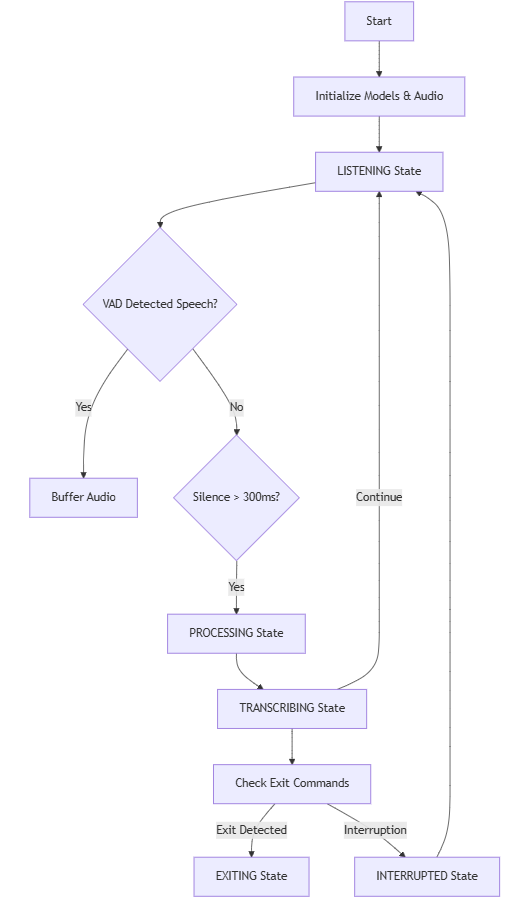

Step-by-Step Code Breakdown

1. Initialization & Cleanup

    Registers signal handlers for SIGINT/SIGTERM

    Sets up atexit cleanup routine

    Loads Whisper-tiny ASR model with progress indicator

    Configures audio stream at 16kHz

2. State Management

    VAD Processing:

        30ms frames analyzed for speech presence

        Maintains speech/silence statistics

    Audio Buffering:

        Collects audio during speech segments

        Triggers processing after 300ms silence

    Visual Feedback:

        Rich live dashboard with color-coded states

        Speech activity timeline visualization

3. Speech Processing

    Concatenates buffered audio

    Normalizes to float32 for ASR

    Uses Whisper with chunked processing

    Returns transcribed text with timestamps

4. Command Analysis

    Exit Detection:

        20+ natural language exit phrases

        Includes "exit now", "stop program", "emergency exit"

    Interruption Recognition:

        Keyword triggers ("stop", "cancel")

        Pattern matching ("wait wait", "that's enough")

        Simulates contextual responses

5. Error Handling

    Audio read timeouts with overflow protection

    VAD exception handling

    ASR fallback for short utterances

    Visual error reporting with timestamps

6. Graceful Shutdown

    Session statistics summary

    Recent transcription log

    Stream termination safeguards

    Resource cleanup verification



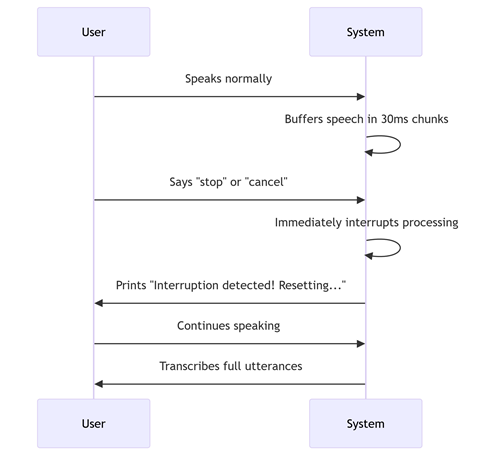

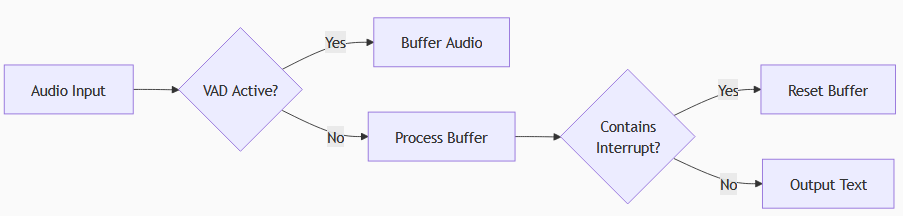

In [2]:
!pip install webrtcvad

  Using cached webrtcvad-2.0.10-cp310-cp310-win_amd64.whl


In [7]:
!pip install colorama rich

In [10]:
# Enhanced VAD and Interruption Handling Demo for Advanced Voice Interaction
# Install: pip install pyaudio webrtcvad transformers torchaudio numpy colorama rich

import torch
import torchaudio
import numpy as np
from transformers import pipeline
import pyaudio
import webrtcvad
import time
import threading
from collections import deque
from datetime import datetime
import sys

# Enhanced imports for visual appeal
try:
    from colorama import init, Fore, Back, Style
    from rich.console import Console
    from rich.live import Live
    from rich.panel import Panel
    from rich.progress import Progress, BarColumn, TextColumn
    from rich.table import Table
    from rich.text import Text
    init()
    console = Console()
    RICH_AVAILABLE = True
except ImportError:
    print("For enhanced visuals, install: pip install colorama rich")
    RICH_AVAILABLE = False

class VoiceInteractionDemo:
    def __init__(self):
        """Initialize the enhanced VAD demonstration system"""
        self.setup_models()
        self.setup_audio()
        self.setup_state_tracking()
        
    def setup_models(self):
        """Initialize ASR with progress indication"""
        if RICH_AVAILABLE:
            with console.status("[bold green]Loading Whisper model..."):
                self.asr_pipe = pipeline(
                    "automatic-speech-recognition",
                    model="openai/whisper-tiny.en",
                    torch_dtype=torch.float16,
                    chunk_length_s=5
                )
            console.print("✅ ASR Model loaded successfully!", style="bold green")
        else:
            print("Loading Whisper model...")
            self.asr_pipe = pipeline(
                "automatic-speech-recognition",
                model="openai/whisper-tiny.en",
                torch_dtype=torch.float16,
                chunk_length_s=5
            )
            print("✅ ASR Model loaded!")
        
        # VAD Configuration
        self.vad = webrtcvad.Vad(2)
        self.SAMPLE_RATE = 16000
        self.FRAME_MS = 30
        self.CHUNK_SIZE = int(self.SAMPLE_RATE * self.FRAME_MS / 1000)
        
    def setup_audio(self):
        """Setup audio stream with error handling"""
        try:
            self.p = pyaudio.PyAudio()
            self.stream = self.p.open(
                format=pyaudio.paInt16,
                channels=1,
                rate=self.SAMPLE_RATE,
                input=True,
                frames_per_buffer=self.CHUNK_SIZE
            )
        except Exception as e:
            print(f"❌ Audio setup failed: {e}")
            sys.exit(1)
            
    def setup_state_tracking(self):
        """Initialize state tracking for demonstration"""
        self.buffer = []
        self.speech_history = deque(maxlen=100)  # Last 100 speech/silence states
        self.transcriptions = []
        self.interruptions = []
        self.stats = {
            'total_chunks': 0,
            'speech_chunks': 0,
            'silence_chunks': 0,
            'transcriptions': 0,
            'interruptions': 0,
            'start_time': time.time()
        }
        self.current_state = "LISTENING"
        self.last_speech_time = 0
        
    def create_status_display(self):
        """Create rich status display"""
        if not RICH_AVAILABLE:
            return None
            
        # Runtime stats
        runtime = time.time() - self.stats['start_time']
        speech_ratio = (self.stats['speech_chunks'] / max(1, self.stats['total_chunks'])) * 100
        
        # Create main table
        table = Table(title="🎤 Voice Activity Detection & Interruption Demo", show_header=True)
        table.add_column("Metric", style="cyan", width=20)
        table.add_column("Value", style="white", width=30)
        table.add_column("Visual", style="green", width=20)
        
        # Add rows with current stats
        table.add_row("🎯 Current State", 
                     f"[bold]{self.current_state}[/bold]",
                     self.get_state_indicator())
        
        table.add_row("⏱️ Runtime", 
                     f"{runtime:.1f}s",
                     "")
        
        table.add_row("🔊 Speech Ratio", 
                     f"{speech_ratio:.1f}%",
                     self.create_bar(speech_ratio, 100))
        
        table.add_row("📝 Transcriptions", 
                     str(self.stats['transcriptions']),
                     "")
        
        table.add_row("⚡ Interruptions", 
                     str(self.stats['interruptions']),
                     "")
        
        # Recent activity visualization
        activity_viz = self.create_activity_visualization()
        table.add_row("📊 Recent Activity", 
                     activity_viz,
                     "")
        
        return Panel(table, border_style="bright_blue")
    
    def get_state_indicator(self):
        """Get visual indicator for current state"""
        indicators = {
            "LISTENING": "🟢 Active",
            "PROCESSING": "🟡 Working",
            "INTERRUPTED": "🔴 Stopped",
            "TRANSCRIBING": "🟦 Converting"
        }
        return indicators.get(self.current_state, "⚪ Unknown")
    
    def create_bar(self, value, max_value, width=10):
        """Create simple ASCII progress bar"""
        filled = int((value / max_value) * width)
        return "█" * filled + "░" * (width - filled)
    
    def create_activity_visualization(self):
        """Create visualization of recent speech activity"""
        if not self.speech_history:
            return "No data yet..."
        
        # Show last 20 states as visual pattern
        recent = list(self.speech_history)[-20:]
        viz = ""
        for state in recent:
            if state:
                viz += "🟢"  # Speech detected
            else:
                viz += "⚫"  # Silence
        
        return viz if viz else "Initializing..."
    
    def print_enhanced_output(self, message, msg_type="info"):
        """Enhanced console output with colors and formatting"""
        timestamp = datetime.now().strftime("%H:%M:%S")
        
        if not RICH_AVAILABLE:
            print(f"[{timestamp}] {message}")
            return
            
        if msg_type == "speech":
            console.print(f"[{timestamp}] 🗣️  [bold blue]USER:[/bold blue] {message}")
        elif msg_type == "interruption":
            console.print(f"[{timestamp}] ⚡ [bold red]INTERRUPTION DETECTED![/bold red] {message}")
        elif msg_type == "processing":
            console.print(f"[{timestamp}] 🔄 [yellow]Processing audio buffer...[/yellow]")
        elif msg_type == "error":
            console.print(f"[{timestamp}] ❌ [bold red]ERROR:[/bold red] {message}")
        elif msg_type == "success":
            console.print(f"[{timestamp}] ✅ [bold green]{message}[/bold green]")
        else:
            console.print(f"[{timestamp}] ℹ️  {message}")
    
    def check_interruption_patterns(self, text):
        """Enhanced interruption detection with pattern matching"""
        interruption_triggers = [
            "stop", "cancel", "halt", "pause", "wait",
            "interrupt", "break", "enough", "silence"
        ]
        
        advanced_patterns = [
            ("hey stop", "Direct command"),
            ("that's enough", "Polite interruption"), 
            ("wait wait", "Urgent pause"),
            ("cancel that", "Cancellation request"),
            ("be quiet", "Silence request")
        ]
        
        text_lower = text.lower()
        
        # Check basic triggers
        for trigger in interruption_triggers:
            if trigger in text_lower:
                return True, f"Keyword '{trigger}' detected"
        
        # Check advanced patterns
        for pattern, description in advanced_patterns:
            if pattern in text_lower:
                return True, description
                
        return False, None
    
    def simulate_response_interruption(self, interruption_reason):
        """Simulate system response to interruption"""
        responses = [
            "🤖 Understood. Stopping current operation.",
            "🤖 Voice command received. Pausing system.",
            "🤖 Interruption acknowledged. Ready for new input.",
            "🤖 System halted per voice command.",
            "🤖 Processing stopped. Awaiting instructions."
        ]
        
        import random
        response = random.choice(responses)
        self.print_enhanced_output(f"{response} (Reason: {interruption_reason})", "interruption")
        
        # Add dramatic pause for demonstration
        time.sleep(1)
        self.print_enhanced_output("System ready for new commands.", "success")
    
    def handle_interaction(self):
        """Main interaction loop with enhanced visualization"""
        self.print_enhanced_output("🎤 Enhanced Voice Interaction Demo Started!", "success")
        self.print_enhanced_output("Try saying: 'Hello', 'Stop please', 'Cancel that', etc.", "info")
        self.print_enhanced_output("Press Ctrl+C to exit", "info")
        
        if RICH_AVAILABLE:
            console.print("\n" + "="*60)
            
        try:
            if RICH_AVAILABLE:
                with Live(self.create_status_display(), refresh_per_second=4) as live:
                    self._main_loop(live)
            else:
                self._main_loop(None)
                
        except KeyboardInterrupt:
            self.cleanup()
    
    def _main_loop(self, live_display):
        """Main processing loop"""
        consecutive_silence = 0
        
        while True:
            try:
                # Read audio chunk
                audio_chunk = np.frombuffer(self.stream.read(self.CHUNK_SIZE), dtype=np.int16)
                self.stats['total_chunks'] += 1
                
                # VAD detection
                is_speech = self.vad.is_speech(audio_chunk.tobytes(), self.SAMPLE_RATE)
                self.speech_history.append(is_speech)
                
                if is_speech:
                    self.stats['speech_chunks'] += 1
                    self.buffer.append(audio_chunk)
                    self.current_state = "LISTENING"
                    self.last_speech_time = time.time()
                    consecutive_silence = 0
                else:
                    self.stats['silence_chunks'] += 1
                    consecutive_silence += 1
                    
                    # Process buffer if we have speech and recent silence
                    if self.buffer and consecutive_silence > 10:  # ~300ms of silence
                        self.current_state = "PROCESSING"
                        if live_display:
                            live_display.update(self.create_status_display())
                        
                        self.print_enhanced_output("Audio buffer captured, transcribing...", "processing")
                        self.process_audio_buffer()
                        consecutive_silence = 0
                
                # Update live display
                if live_display:
                    live_display.update(self.create_status_display())
                    
            except Exception as e:
                self.print_enhanced_output(f"Processing error: {e}", "error")
                self.buffer = []  # Clear buffer on error
    
    def process_audio_buffer(self):
        """Process accumulated audio buffer"""
        if not self.buffer:
            return
            
        self.current_state = "TRANSCRIBING"
        
        try:
            # Convert audio to format expected by ASR
            audio_np = np.concatenate(self.buffer).astype(np.float32) / 32768.0
            
            # Transcribe
            result = self.asr_pipe(
                {"raw": audio_np, "sampling_rate": self.SAMPLE_RATE},
                return_timestamps=True,
                generate_kwargs={"max_new_tokens": 50}
            )
            
            text = result["text"].strip()
            
            if text and len(text) > 2:  # Filter out very short/empty transcriptions
                self.stats['transcriptions'] += 1
                self.transcriptions.append({
                    'text': text,
                    'timestamp': datetime.now(),
                    'buffer_size': len(self.buffer)
                })
                
                self.print_enhanced_output(text, "speech")
                
                # Check for interruptions
                is_interruption, reason = self.check_interruption_patterns(text)
                if is_interruption:
                    self.stats['interruptions'] += 1
                    self.current_state = "INTERRUPTED"
                    self.interruptions.append({
                        'text': text,
                        'reason': reason,
                        'timestamp': datetime.now()
                    })
                    self.simulate_response_interruption(reason)
                
        except Exception as e:
            self.print_enhanced_output(f"Transcription failed: {e}", "error")
        
        finally:
            self.buffer = []
            self.current_state = "LISTENING"
    
    def cleanup(self):
        """Clean shutdown with summary"""
        self.print_enhanced_output("\n🛑 Shutting down Voice Interaction Demo", "info")
        
        # Show session summary
        runtime = time.time() - self.stats['start_time']
        self.print_enhanced_output(f"📊 Session Summary:", "success")
        self.print_enhanced_output(f"   Runtime: {runtime:.1f} seconds", "info")
        self.print_enhanced_output(f"   Total transcriptions: {self.stats['transcriptions']}", "info")
        self.print_enhanced_output(f"   Interruptions detected: {self.stats['interruptions']}", "info")
        self.print_enhanced_output(f"   Speech activity: {(self.stats['speech_chunks']/max(1,self.stats['total_chunks'])*100):.1f}%", "info")
        
        # Show recent transcriptions
        if self.transcriptions:
            self.print_enhanced_output("📝 Recent transcriptions:", "info")
            for trans in self.transcriptions[-3:]:
                self.print_enhanced_output(f"   '{trans['text']}'", "info")
        
        # Cleanup audio
        try:
            self.stream.stop_stream()
            self.stream.close()
            self.p.terminate() 
        except:
            pass
        
        self.print_enhanced_output("👋 Demo ended. Thank you!", "success")

# Demo launcher
if __name__ == "__main__":
    try:
        demo = VoiceInteractionDemo()
        demo.handle_interaction()
    except Exception as e:
        print(f"❌ Demo failed to start: {e}")
        print("Make sure you have: pip install pyaudio webrtcvad transformers torchaudio numpy")
        print("For enhanced visuals: pip install colorama rich")

Output()

Device set to use cpu
Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


✅ ASR Model loaded successfully!

[11:52:15] ✅ 🎤 Enhanced Voice Interaction Demo Started!

[11:52:15] ℹ️  Try saying: 'Hello', 'Stop please', 'Cancel that', etc.

...

[11:53:41] ℹ️  📝 Recent transcriptions:

[11:53:41] ℹ️     'So,'

[11:53:41] ℹ️     'are listening to me.'

[11:53:41] ℹ️     'Thank you for watching! Thank you for watching! Thank you for watching! Thank you for watching! 
Thank you for watching! Thank you for watching! Thank you for watching! Thank you so much for watching and I'll see
you in the next video, see you in the next video, see you in the next video, see you in the next video, see you in 
the next video, see you in the next'

[11:53:41] ✅ 👋 Demo ended. Thank you!

In [9]:
# Enhanced VAD and Interruption Handling Demo with Reliable Exit Methods
# Install: pip install pyaudio webrtcvad transformers torchaudio numpy colorama rich

import torch
import torchaudio
import numpy as np
from transformers import pipeline
import pyaudio
import webrtcvad
import time
import threading
from collections import deque
from datetime import datetime
import sys
import signal
import atexit

# Enhanced imports for visual appeal
try:
    from colorama import init, Fore, Back, Style
    from rich.console import Console
    from rich.live import Live
    from rich.panel import Panel
    from rich.progress import Progress, BarColumn, TextColumn
    from rich.table import Table
    from rich.text import Text
    init()
    console = Console()
    RICH_AVAILABLE = True
except ImportError:
    print("For enhanced visuals, install: pip install colorama rich")
    RICH_AVAILABLE = False

class VoiceInteractionDemo:
    def __init__(self):
        """Initialize the enhanced VAD demonstration system"""
        self.running = True
        self.exit_requested = False
        self.cleanup_done = False
        
        # Register cleanup handlers
        atexit.register(self.cleanup)
        signal.signal(signal.SIGINT, self.signal_handler)
        signal.signal(signal.SIGTERM, self.signal_handler)
        
        self.setup_models()
        self.setup_audio()
        self.setup_state_tracking()
        
    def signal_handler(self, signum, frame):
        """Handle system signals for graceful shutdown"""
        print(f"\n🛑 Signal {signum} received. Initiating shutdown...")
        self.exit_requested = True
        self.running = False
        
    def setup_models(self):
        """Initialize ASR with progress indication"""
        if RICH_AVAILABLE:
            with console.status("[bold green]Loading Whisper model..."):
                self.asr_pipe = pipeline(
                    "automatic-speech-recognition",
                    model="openai/whisper-tiny.en",
                    torch_dtype=torch.float16,
                    chunk_length_s=5
                )
            console.print("✅ ASR Model loaded successfully!", style="bold green")
        else:
            print("Loading Whisper model...")
            self.asr_pipe = pipeline(
                "automatic-speech-recognition",
                model="openai/whisper-tiny.en",
                torch_dtype=torch.float16,
                chunk_length_s=5
            )
            print("✅ ASR Model loaded!")
        
        # VAD Configuration
        self.vad = webrtcvad.Vad(2)
        self.SAMPLE_RATE = 16000
        self.FRAME_MS = 30
        self.CHUNK_SIZE = int(self.SAMPLE_RATE * self.FRAME_MS / 1000)
        
    def setup_audio(self):
        """Setup audio stream with error handling"""
        try:
            self.p = pyaudio.PyAudio()
            self.stream = self.p.open(
                format=pyaudio.paInt16,
                channels=1,
                rate=self.SAMPLE_RATE,
                input=True,
                frames_per_buffer=self.CHUNK_SIZE
            )
        except Exception as e:
            print(f"❌ Audio setup failed: {e}")
            sys.exit(1)
            
    def setup_state_tracking(self):
        """Initialize state tracking for demonstration"""
        self.buffer = []
        self.speech_history = deque(maxlen=100)
        self.transcriptions = []
        self.interruptions = []
        self.stats = {
            'total_chunks': 0,
            'speech_chunks': 0,
            'silence_chunks': 0,
            'transcriptions': 0,
            'interruptions': 0,
            'start_time': time.time()
        }
        self.current_state = "LISTENING"
        self.last_speech_time = 0
        
    def create_status_display(self):
        """Create rich status display"""
        if not RICH_AVAILABLE:
            return None
            
        # Runtime stats
        runtime = time.time() - self.stats['start_time']
        speech_ratio = (self.stats['speech_chunks'] / max(1, self.stats['total_chunks'])) * 100
        
        # Create main table
        table = Table(title="🎤 Voice Activity Detection & Interruption Demo", show_header=True)
        table.add_column("Metric", style="cyan", width=20)
        table.add_column("Value", style="white", width=30)
        table.add_column("Visual", style="green", width=20)
        
        # Add rows with current stats
        table.add_row("🎯 Current State", 
                     f"[bold]{self.current_state}[/bold]",
                     self.get_state_indicator())
        
        table.add_row("⏱️ Runtime", 
                     f"{runtime:.1f}s",
                     "")
        
        table.add_row("🔊 Speech Ratio", 
                     f"{speech_ratio:.1f}%",
                     self.create_bar(speech_ratio, 100))
        
        table.add_row("📝 Transcriptions", 
                     str(self.stats['transcriptions']),
                     "")
        
        table.add_row("⚡ Interruptions", 
                     str(self.stats['interruptions']),
                     "")
        
        # Recent activity visualization
        activity_viz = self.create_activity_visualization()
        table.add_row("📊 Recent Activity", 
                     activity_viz,
                     "")
        
        # Exit instructions
        table.add_row("🚪 Exit Options", 
                     "Say 'exit now' OR press Ctrl+C twice",
                     "")
        
        return Panel(table, border_style="bright_blue")
    
    def get_state_indicator(self):
        """Get visual indicator for current state"""
        indicators = {
            "LISTENING": "🟢 Active",
            "PROCESSING": "🟡 Working",
            "INTERRUPTED": "🔴 Stopped",
            "TRANSCRIBING": "🟦 Converting",
            "EXITING": "🚪 Shutting Down"
        }
        return indicators.get(self.current_state, "⚪ Unknown")
    
    def create_bar(self, value, max_value, width=10):
        """Create simple ASCII progress bar"""
        filled = int((value / max_value) * width)
        return "█" * filled + "░" * (width - filled)
    
    def create_activity_visualization(self):
        """Create visualization of recent speech activity"""
        if not self.speech_history:
            return "No data yet..."
        
        # Show last 20 states as visual pattern
        recent = list(self.speech_history)[-20:]
        viz = ""
        for state in recent:
            if state:
                viz += "🟢"  # Speech detected
            else:
                viz += "⚫"  # Silence
        
        return viz if viz else "Initializing..."
    
    def print_enhanced_output(self, message, msg_type="info"):
        """Enhanced console output with colors and formatting"""
        if not self.running:
            return
            
        timestamp = datetime.now().strftime("%H:%M:%S")
        
        if not RICH_AVAILABLE:
            print(f"[{timestamp}] {message}")
            return
            
        if msg_type == "speech":
            console.print(f"[{timestamp}] 🗣️  [bold blue]USER:[/bold blue] {message}")
        elif msg_type == "interruption":
            console.print(f"[{timestamp}] ⚡ [bold red]INTERRUPTION DETECTED![/bold red] {message}")
        elif msg_type == "processing":
            console.print(f"[{timestamp}] 🔄 [yellow]Processing audio buffer...[/yellow]")
        elif msg_type == "error":
            console.print(f"[{timestamp}] ❌ [bold red]ERROR:[/bold red] {message}")
        elif msg_type == "success":
            console.print(f"[{timestamp}] ✅ [bold green]{message}[/bold green]")
        elif msg_type == "exit":
            console.print(f"[{timestamp}] 🚪 [bold magenta]{message}[/bold magenta]")
        else:
            console.print(f"[{timestamp}] ℹ️  {message}")
    
    def check_exit_commands(self, text):
        """Check for various exit commands"""
        exit_phrases = [
            # Simple commands
            "exit", "quit", "stop program", "end demo",
            "shutdown", "terminate", "close program",
            
            # Natural language commands
            "exit now", "quit now", "stop listening", 
            "end session", "finish demo", "that's all",
            "goodbye", "bye bye", "see you later",
            
            # Emergency commands
            "emergency exit", "force quit", "kill program",
            "abort", "cancel everything"
        ]
        
        text_lower = text.lower().strip()
        
        for phrase in exit_phrases:
            if phrase in text_lower:
                return True, phrase
                
        return False, None
    
    def check_interruption_patterns(self, text):
        """Enhanced interruption detection with pattern matching"""
        interruption_triggers = [
            "stop", "cancel", "halt", "pause", "wait",
            "interrupt", "break", "enough", "silence"
        ]
        
        advanced_patterns = [
            ("hey stop", "Direct command"),
            ("that's enough", "Polite interruption"), 
            ("wait wait", "Urgent pause"),
            ("cancel that", "Cancellation request"),
            ("be quiet", "Silence request")
        ]
        
        text_lower = text.lower()
        
        # Check basic triggers
        for trigger in interruption_triggers:
            if trigger in text_lower:
                return True, f"Keyword '{trigger}' detected"
        
        # Check advanced patterns
        for pattern, description in advanced_patterns:
            if pattern in text_lower:
                return True, description
                
        return False, None
    
    def simulate_response_interruption(self, interruption_reason):
        """Simulate system response to interruption"""
        if not self.running:
            return
            
        responses = [
            "🤖 Understood. Stopping current operation.",
            "🤖 Voice command received. Pausing system.",
            "🤖 Interruption acknowledged. Ready for new input.",
            "🤖 System halted per voice command.",
            "🤖 Processing stopped. Awaiting instructions."
        ]
        
        import random
        response = random.choice(responses)
        self.print_enhanced_output(f"{response} (Reason: {interruption_reason})", "interruption")
        
        # Add dramatic pause for demonstration
        time.sleep(1)
        if self.running:
            self.print_enhanced_output("System ready for new commands.", "success")
    
    def safe_exit(self, reason="Unknown"):
        """Safely exit the program"""
        self.print_enhanced_output(f"🚪 Exit requested: {reason}", "exit")
        self.current_state = "EXITING"
        self.running = False
        self.exit_requested = True
        
        # Small delay to ensure message is printed
        time.sleep(0.5)
        
        # Force exit after cleanup
        self.cleanup()
        sys.exit(0)
    
    def handle_interaction(self):
        """Main interaction loop with enhanced visualization and reliable exit"""
        self.print_enhanced_output("🎤 Enhanced Voice Interaction Demo Started!", "success")
        self.print_enhanced_output("🗣️  Try saying: 'Hello', 'Stop please', 'Cancel that'", "info")
        self.print_enhanced_output("🚪 To EXIT say: 'exit now', 'quit', 'stop program'", "exit")
        self.print_enhanced_output("⌨️  Or press Ctrl+C (may need to press twice)", "info")
        
        if RICH_AVAILABLE:
            console.print("\n" + "="*60)
            
        try:
            if RICH_AVAILABLE:
                with Live(self.create_status_display(), refresh_per_second=4) as live:
                    self._main_loop(live)
            else:
                self._main_loop(None)
                
        except KeyboardInterrupt:
            self.safe_exit("Keyboard Interrupt")
        except Exception as e:
            self.print_enhanced_output(f"Unexpected error: {e}", "error")
            self.safe_exit("Error occurred")
    
    def _main_loop(self, live_display):
        """Main processing loop with timeout protection"""
        consecutive_silence = 0
        loop_count = 0
        
        while self.running and not self.exit_requested:
            try:
                loop_count += 1
                
                # Periodic check for exit condition
                if loop_count % 100 == 0:  # Every ~3 seconds
                    if self.exit_requested:
                        break
                
                # Read audio chunk with timeout protection
                try:
                    audio_chunk = np.frombuffer(
                        self.stream.read(self.CHUNK_SIZE, exception_on_overflow=False), 
                        dtype=np.int16
                    )
                except Exception as e:
                    if self.running:
                        self.print_enhanced_output(f"Audio read error: {e}", "error")
                    continue
                
                if not self.running:
                    break
                    
                self.stats['total_chunks'] += 1
                
                # VAD detection
                try:
                    is_speech = self.vad.is_speech(audio_chunk.tobytes(), self.SAMPLE_RATE)
                    self.speech_history.append(is_speech)
                except Exception as e:
                    if self.running:
                        self.print_enhanced_output(f"VAD error: {e}", "error")
                    continue
                
                if is_speech:
                    self.stats['speech_chunks'] += 1
                    self.buffer.append(audio_chunk)
                    self.current_state = "LISTENING"
                    self.last_speech_time = time.time()
                    consecutive_silence = 0
                else:
                    self.stats['silence_chunks'] += 1
                    consecutive_silence += 1
                    
                    # Process buffer if we have speech and recent silence
                    if self.buffer and consecutive_silence > 10:  # ~300ms of silence
                        if not self.running:
                            break
                        self.current_state = "PROCESSING"
                        if live_display:
                            live_display.update(self.create_status_display())
                        
                        self.print_enhanced_output("Audio buffer captured, transcribing...", "processing")
                        exit_detected = self.process_audio_buffer()
                        
                        if exit_detected:
                            break
                            
                        consecutive_silence = 0
                
                # Update live display
                if live_display and self.running:
                    live_display.update(self.create_status_display())
                    
            except KeyboardInterrupt:
                self.safe_exit("Keyboard Interrupt in loop")
                break
            except Exception as e:
                if self.running:
                    self.print_enhanced_output(f"Loop error: {e}", "error")
                continue
    
    def process_audio_buffer(self):
        """Process accumulated audio buffer, return True if exit detected"""
        if not self.buffer or not self.running:
            return False
            
        self.current_state = "TRANSCRIBING"
        
        try:
            # Convert audio to format expected by ASR
            audio_np = np.concatenate(self.buffer).astype(np.float32) / 32768.0
            
            # Transcribe
            result = self.asr_pipe(
                {"raw": audio_np, "sampling_rate": self.SAMPLE_RATE},
                return_timestamps=True,
                generate_kwargs={"max_new_tokens": 50}
            )
            
            text = result["text"].strip()
            
            if text and len(text) > 2:  # Filter out very short/empty transcriptions
                self.stats['transcriptions'] += 1
                self.transcriptions.append({
                    'text': text,
                    'timestamp': datetime.now(),
                    'buffer_size': len(self.buffer)
                })
                
                self.print_enhanced_output(text, "speech")
                
                # Check for exit commands FIRST
                is_exit, exit_phrase = self.check_exit_commands(text)
                if is_exit:
                    self.safe_exit(f"Voice command: '{exit_phrase}'")
                    return True
                
                # Check for interruptions
                is_interruption, reason = self.check_interruption_patterns(text)
                if is_interruption:
                    self.stats['interruptions'] += 1
                    self.current_state = "INTERRUPTED"
                    self.interruptions.append({
                        'text': text,
                        'reason': reason,
                        'timestamp': datetime.now()
                    })
                    self.simulate_response_interruption(reason)
                
        except Exception as e:
            if self.running:
                self.print_enhanced_output(f"Transcription failed: {e}", "error")
        
        finally:
            self.buffer = []
            if self.running:
                self.current_state = "LISTENING"
        
        return False
    
    def cleanup(self):
        """Clean shutdown with summary"""
        if self.cleanup_done:
            return
        
        self.cleanup_done = True
        self.running = False
        
        try:
            self.print_enhanced_output("\n🛑 Shutting down Voice Interaction Demo", "exit")
            
            # Show session summary
            runtime = time.time() - self.stats['start_time']
            self.print_enhanced_output(f"📊 Session Summary:", "success")
            self.print_enhanced_output(f"   Runtime: {runtime:.1f} seconds", "info")
            self.print_enhanced_output(f"   Total transcriptions: {self.stats['transcriptions']}", "info")
            self.print_enhanced_output(f"   Interruptions detected: {self.stats['interruptions']}", "info")
            self.print_enhanced_output(f"   Speech activity: {(self.stats['speech_chunks']/max(1,self.stats['total_chunks'])*100):.1f}%", "info")
            
            # Show recent transcriptions
            if self.transcriptions:
                self.print_enhanced_output("📝 Recent transcriptions:", "info")
                for trans in self.transcriptions[-3:]:
                    self.print_enhanced_output(f"   '{trans['text']}'", "info")
            
            # Cleanup audio
            if hasattr(self, 'stream'):
                try:
                    self.stream.stop_stream()
                    self.stream.close()
                except:
                    pass
            
            if hasattr(self, 'p'):
                try:
                    self.p.terminate()
                except:
                    pass
            
            self.print_enhanced_output("👋 Demo ended successfully!", "success")
            
        except Exception as e:
            print(f"Cleanup error: {e}")

# Demo launcher with additional protection
if __name__ == "__main__":
    try:
        demo = VoiceInteractionDemo()
        demo.handle_interaction()
    except KeyboardInterrupt:
        print("\n🛑 Program interrupted by user")
        sys.exit(0)
    except Exception as e:
        print(f"❌ Demo failed to start: {e}")
        print("Make sure you have: pip install pyaudio webrtcvad transformers torchaudio numpy")
        print("For enhanced visuals: pip install colorama rich")
        sys.exit(1)

Output()

Device set to use cpu
Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


✅ ASR Model loaded successfully!

[10:59:07] ✅ 🎤 Enhanced Voice Interaction Demo Started!

[10:59:07] ℹ️  🗣️  Try saying: 'Hello', 'Stop please', 'Cancel that'

...

[10:59:49] 🔄 Processing audio buffer...

[10:59:52] 🗣️  USER: Okay, exit now.

[10:59:52] 🚪 🚪 Exit requested: Voice command: 'exit'

SystemExit: 0

C:\Users\vinit_hqjv9wt\anaconda3\envs\speechlm_alt\lib\site-packages\IPython\core\interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
